# Persistence

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()

llm = ChatOpenAI()

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str
    

In [5]:
def generate_joke(state: JokeState) -> JokeState:

    prompt = f'Generate a joke on the topic {state['topic']}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [6]:
def generate_explanation(state: JokeState) -> JokeState:

    prompt = f'write an explanation for the job - {state['joke']}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

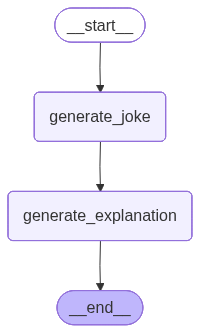

In [7]:
# graph
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer = InMemorySaver()

graph.compile(checkpointer=checkpointer)

In [8]:
workflow = graph.compile(checkpointer=checkpointer)

In [9]:
config = {'configurable': {'thread_id':'1'}}

workflow.invoke({'topic':'langchain'}, config=config)

{'topic': 'langchain',
 'joke': "Why did the programmer break up with their girlfriend? Because she couldn't handle their long chain of codependency!",
 'explanation': 'This joke is a play on words, combining the term "chain of code" in programming with the idea of codependency in relationships. In programming, a long chain of code refers to a series of commands or functions that are interconnected and reliant on each other. In a relationship, codependency refers to a dysfunctional, one-sided reliance on another person for emotional support or validation.\n\nThe joke suggests that the programmer\'s girlfriend couldn\'t handle their long chain of codependency, meaning that she was unable to cope with the programmer\'s dependency on her for support or validation. This humorous explanation for the breakup highlights the idea that a healthy relationship requires mutual respect, independence, and the ability to support each other without being overly reliant on the other person.'}

In [10]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'langchain', 'joke': "Why did the programmer break up with their girlfriend? Because she couldn't handle their long chain of codependency!", 'explanation': 'This joke is a play on words, combining the term "chain of code" in programming with the idea of codependency in relationships. In programming, a long chain of code refers to a series of commands or functions that are interconnected and reliant on each other. In a relationship, codependency refers to a dysfunctional, one-sided reliance on another person for emotional support or validation.\n\nThe joke suggests that the programmer\'s girlfriend couldn\'t handle their long chain of codependency, meaning that she was unable to cope with the programmer\'s dependency on her for support or validation. This humorous explanation for the breakup highlights the idea that a healthy relationship requires mutual respect, independence, and the ability to support each other without being overly reliant on the other 

In [11]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'langchain', 'joke': "Why did the programmer break up with their girlfriend? Because she couldn't handle their long chain of codependency!", 'explanation': 'This joke is a play on words, combining the term "chain of code" in programming with the idea of codependency in relationships. In programming, a long chain of code refers to a series of commands or functions that are interconnected and reliant on each other. In a relationship, codependency refers to a dysfunctional, one-sided reliance on another person for emotional support or validation.\n\nThe joke suggests that the programmer\'s girlfriend couldn\'t handle their long chain of codependency, meaning that she was unable to cope with the programmer\'s dependency on her for support or validation. This humorous explanation for the breakup highlights the idea that a healthy relationship requires mutual respect, independence, and the ability to support each other without being overly reliant on the other

In [12]:
config_1 = {'configurable': {'thread_id':'2'}}

workflow.invoke({'topic':'langgraph'}, config=config_1)

{'topic': 'langgraph',
 'joke': 'Why did the linguist refuse to play Scrabble with the computer? Because he was tired of always losing to the langgraph!',
 'explanation': 'A linguist is a person who studies language and its structure. In this case, the linguist refused to play Scrabble with the computer because he was tired of always losing to the langgraph. The term "langgraph" is likely a play on words combining language and graph, implying that the computer is using advanced algorithms and data analysis to consistently outperform the linguist in the game of Scrabble. This joke suggests that the linguist didn\'t want to continue playing a game where he always ended up on the losing side due to the computer\'s superior language processing abilities.'}

In [13]:
workflow.get_state(config_1)

StateSnapshot(values={'topic': 'langgraph', 'joke': 'Why did the linguist refuse to play Scrabble with the computer? Because he was tired of always losing to the langgraph!', 'explanation': 'A linguist is a person who studies language and its structure. In this case, the linguist refused to play Scrabble with the computer because he was tired of always losing to the langgraph. The term "langgraph" is likely a play on words combining language and graph, implying that the computer is using advanced algorithms and data analysis to consistently outperform the linguist in the game of Scrabble. This joke suggests that the linguist didn\'t want to continue playing a game where he always ended up on the losing side due to the computer\'s superior language processing abilities.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168abf-27ac-6987-8002-d797abe1a1fe'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-15T11:18:3

In [14]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'langgraph', 'joke': 'Why did the linguist refuse to play Scrabble with the computer? Because he was tired of always losing to the langgraph!', 'explanation': 'A linguist is a person who studies language and its structure. In this case, the linguist refused to play Scrabble with the computer because he was tired of always losing to the langgraph. The term "langgraph" is likely a play on words combining language and graph, implying that the computer is using advanced algorithms and data analysis to consistently outperform the linguist in the game of Scrabble. This joke suggests that the linguist didn\'t want to continue playing a game where he always ended up on the losing side due to the computer\'s superior language processing abilities.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168abf-27ac-6987-8002-d797abe1a1fe'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-15T11:18:

# Time Travel

In [16]:
workflow.get_state({'configurable':{'thread_id': '2', 'checkpoint_id': '1f168abf-12e0-634c-8001-5e65951ca453'}})

StateSnapshot(values={'topic': 'langgraph', 'joke': 'Why did the linguist refuse to play Scrabble with the computer? Because he was tired of always losing to the langgraph!'}, next=('generate_explanation',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f168abf-12e0-634c-8001-5e65951ca453'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-15T11:18:32.021651+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168abe-fcc5-660e-8000-3a2df28728be'}}, tasks=(PregelTask(id='961b6ad6-b9e8-4005-0303-a9fe5886060a', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': 'A linguist is a person who studies language and its structure. In this case, the linguist refused to play Scrabble with the computer because he was tired of always losing to the langgraph. The term "langgraph" is likely a play on words combining language an

In [17]:
workflow.invoke(None, {'configurable':{'thread_id': '2', 'checkpoint_id': '1f168abf-12e0-634c-8001-5e65951ca453'}})

{'topic': 'langgraph',
 'joke': 'Why did the linguist refuse to play Scrabble with the computer? Because he was tired of always losing to the langgraph!',
 'explanation': 'A linguist is someone who studies language and its structure, meaning, and use. In this joke, the linguist refused to play Scrabble with the computer because he was tired of always losing to the langgraph. \n\nThe term "langgraph" is a play on words, combining "language" with "algorithm." The joke implies that the computer was programmed with a highly advanced algorithm specifically designed for playing Scrabble, making it nearly impossible for the linguist to compete and win.\n\nThis joke is humorous because it highlights the linguist\'s frustration in repeatedly losing to a computer that has been programmed to excel in a game that revolves around language and vocabulary. It also serves as a commentary on the growing influence of technology and artificial intelligence in various aspects of our lives, including compe

In [18]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'langgraph', 'joke': 'Why did the linguist refuse to play Scrabble with the computer? Because he was tired of always losing to the langgraph!', 'explanation': 'A linguist is someone who studies language and its structure, meaning, and use. In this joke, the linguist refused to play Scrabble with the computer because he was tired of always losing to the langgraph. \n\nThe term "langgraph" is a play on words, combining "language" with "algorithm." The joke implies that the computer was programmed with a highly advanced algorithm specifically designed for playing Scrabble, making it nearly impossible for the linguist to compete and win.\n\nThis joke is humorous because it highlights the linguist\'s frustration in repeatedly losing to a computer that has been programmed to excel in a game that revolves around language and vocabulary. It also serves as a commentary on the growing influence of technology and artificial intelligence in various aspects of our li

# Updating State

In [23]:
workflow.update_state({'configurable':{'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168abe-fcc3-6130-bfff-da2a5bdbb590'}}, {'topic': 'langsmith'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f168aee-00fc-6cef-8000-21055223d954'}}

In [24]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'langsmith'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168aee-00fc-6cef-8000-21055223d954'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-06-15T11:39:31.792596+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168abe-fcc3-6130-bfff-da2a5bdbb590'}}, tasks=(PregelTask(id='73478d13-57ec-562c-275c-bf1450d4806b', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'langgraph', 'joke': "Why did the linguist break up with the graph theorist? Because they just couldn't find a common lang-graph!", 'explanation': 'This joke plays on the pun of "lang-graph," combining the words "language" and "graph" to create a humorous reason for the breakup between a linguist and a graph theorist. The joke suggests that th

In [26]:
workflow.invoke(None, {'configurable':{'thread_id': '2', 'checkpoint_id': '1f168aee-00fc-6cef-8000-21055223d954'}})

{'topic': 'langsmith',
 'joke': 'Why did the langsmith refuse to play hide and seek? Because every time they tried to blend in, they ended up standing out!',
 'explanation': "The langsmith refused to play hide and seek because they were so skilled at blending in and disguising themselves that they always ended up standing out instead of hiding effectively. Their talents and expertise made it impossible for them to go unnoticed, making the game unfair for their opponents. The langsmith's refusal to play was not out of arrogance, but rather out of a desire to not ruin the game for others with their exceptional ability to stand out even when trying to hide."}

In [27]:
list(workflow.get_state_history(config_1))

[StateSnapshot(values={'topic': 'langsmith', 'joke': 'Why did the langsmith refuse to play hide and seek? Because every time they tried to blend in, they ended up standing out!', 'explanation': "The langsmith refused to play hide and seek because they were so skilled at blending in and disguising themselves that they always ended up standing out instead of hiding effectively. Their talents and expertise made it impossible for them to go unnoticed, making the game unfair for their opponents. The langsmith's refusal to play was not out of arrogance, but rather out of a desire to not ruin the game for others with their exceptional ability to stand out even when trying to hide."}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f168af0-3685-6475-8002-afdfb42d92cc'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-15T11:40:31.093033+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoi